# Lucky Singh

# DataAnalytics-L1- Sentiment Analysis



In [3]:
import pandas as pd

In [7]:
import pandas as pd

df = pd.read_csv("../data/sentiment_dataset.csv", header=None)

In [8]:
df.columns = ["ID", "Entity", "Sentiment", "Text"]

In [9]:
df.head()

,ID,Entity,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         74682 non-null  int64
 1   Entity     74682 non-null  str  
 2   Sentiment  74682 non-null  str  
 3   Text       73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 11.4 MB


In [11]:
df.isnull().sum()

ID             0
Entity         0
Sentiment      0
Text         686
dtype: int64

In [12]:
print("Rows and Columns:", df.shape)

Rows and Columns: (74682, 4)


In [13]:
print(df.columns)

Index(['ID', 'Entity', 'Sentiment', 'Text'], dtype='str')


In [14]:
print(df["Sentiment"].value_counts())

Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


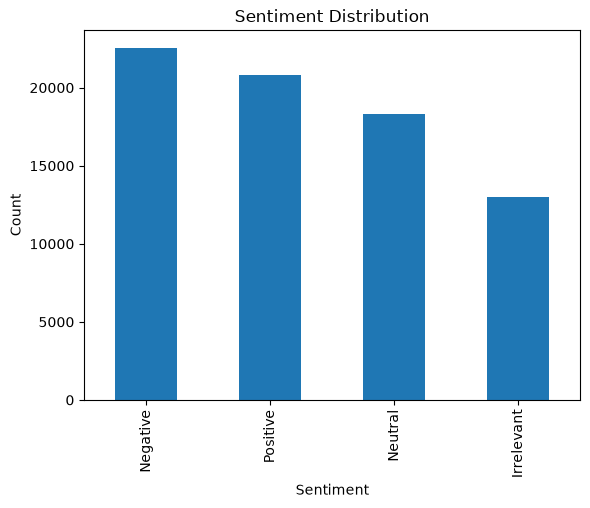

In [15]:
import matplotlib.pyplot as plt

df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [16]:
print(df.isnull().sum())

ID             0
Entity         0
Sentiment      0
Text         686
dtype: int64


In [17]:
df = df.dropna()

In [18]:
df = df[["Text", "Sentiment"]]

In [19]:
df.head()

,Text,Sentiment
0,im getting on borderlands and i will murder yo...,Positive
1,I am coming to the borders and I will kill you...,Positive
2,im getting on borderlands and i will kill you ...,Positive
3,im coming on borderlands and i will murder you...,Positive
4,im getting on borderlands 2 and i will murder ...,Positive


In [21]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/luckysingh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/luckysingh/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [22]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["Clean_Text"] = df["Text"].apply(clean_text)

In [23]:
df.head()

,Text,Sentiment,Clean_Text
0,im getting on borderlands and i will murder yo...,Positive,im getting borderlands murder
1,I am coming to the borders and I will kill you...,Positive,coming borders kill
2,im getting on borderlands and i will kill you ...,Positive,im getting borderlands kill
3,im coming on borderlands and i will murder you...,Positive,im coming borderlands murder
4,im getting on borderlands 2 and i will murder ...,Positive,im getting borderlands murder


## TF-IDF Vectorizer

TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numerical features. It gives higher importance to words that are frequent in a document but less frequent across all documents, making them useful for machine learning models.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["Clean_Text"])

y = df["Sentiment"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(59196, 5000)
(14800, 5000)


In [26]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, nb_predictions))

print(classification_report(y_test, nb_predictions))

Accuracy: 0.6297297297297297
              precision    recall  f1-score   support

  Irrelevant       0.74      0.34      0.47      2696
    Negative       0.62      0.80      0.70      4380
     Neutral       0.66      0.51      0.57      3605
    Positive       0.60      0.74      0.66      4119

    accuracy                           0.63     14800
   macro avg       0.66      0.60      0.60     14800
weighted avg       0.65      0.63      0.62     14800



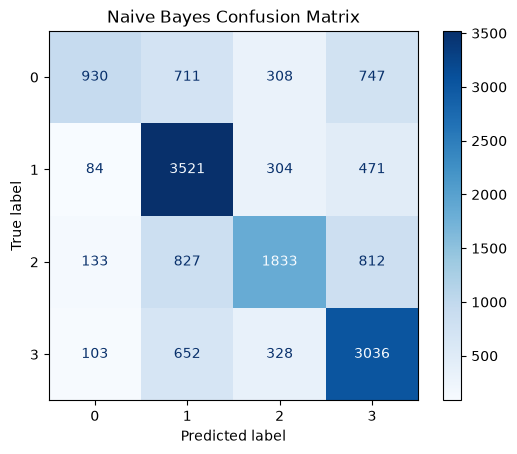

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, nb_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [29]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [30]:
print("Accuracy:", accuracy_score(y_test, lr_predictions))

print(classification_report(y_test, lr_predictions))

Accuracy: 0.6802027027027027
              precision    recall  f1-score   support

  Irrelevant       0.70      0.51      0.59      2696
    Negative       0.72      0.77      0.75      4380
     Neutral       0.62      0.65      0.63      3605
    Positive       0.67      0.72      0.70      4119

    accuracy                           0.68     14800
   macro avg       0.68      0.66      0.67     14800
weighted avg       0.68      0.68      0.68     14800



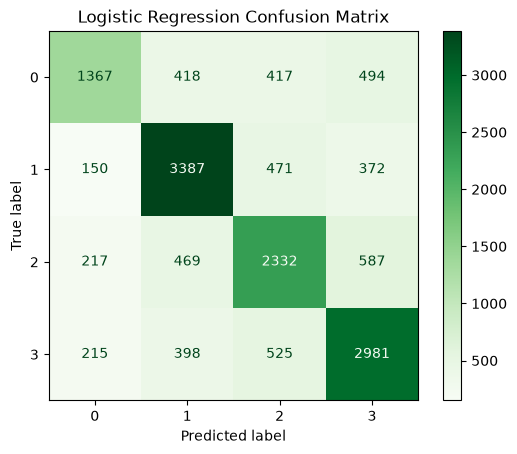

In [31]:
cm = confusion_matrix(y_test, lr_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Greens")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

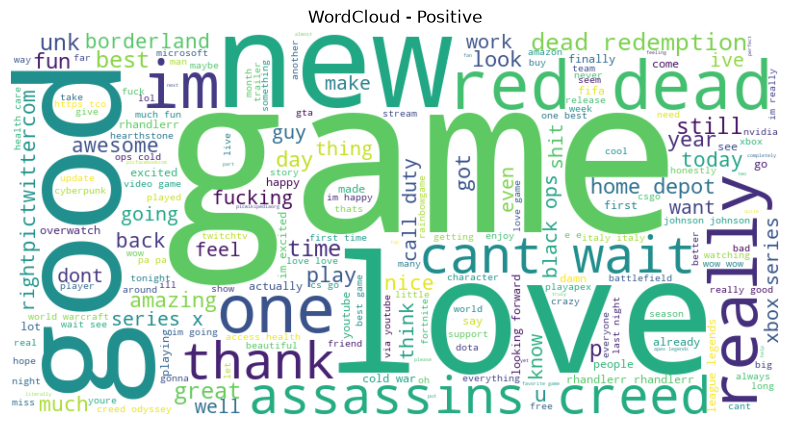

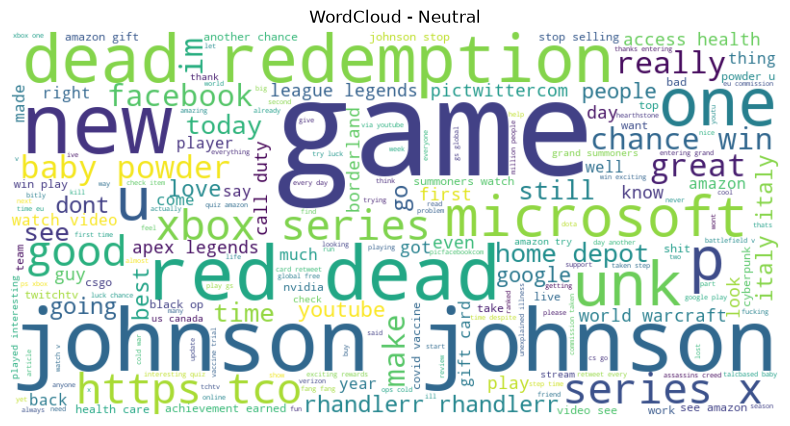

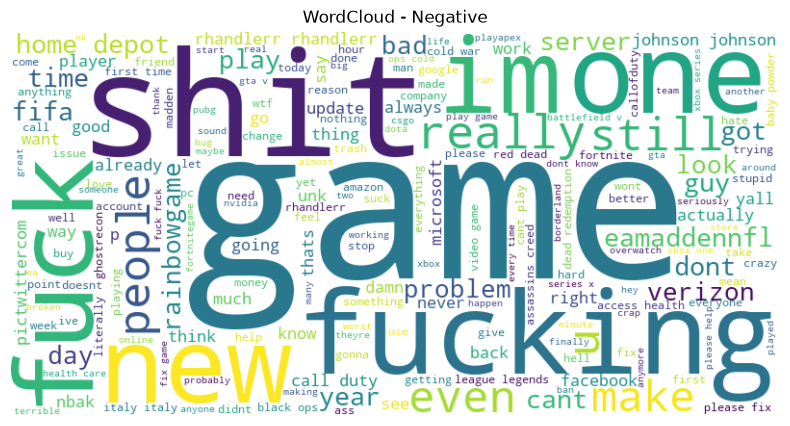

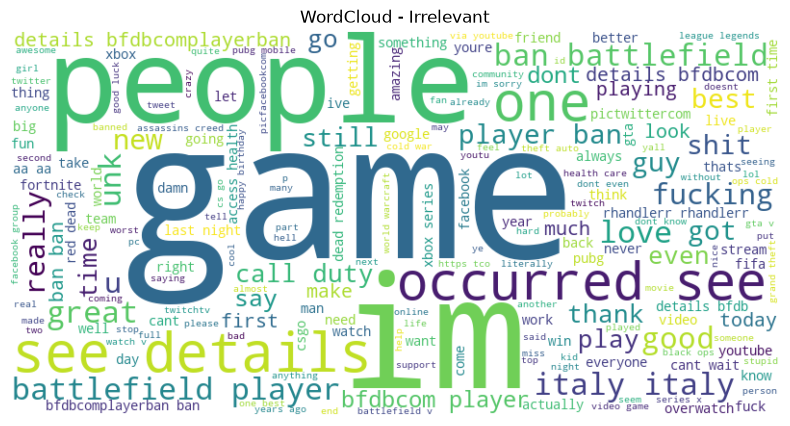

In [32]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for sentiment in df["Sentiment"].unique():

    text = " ".join(df[df["Sentiment"] == sentiment]["Clean_Text"])

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud - {sentiment}")
    plt.show()

In [33]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Text aur labels ko saath me split karna
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    df["Clean_Text"],
    df["Sentiment"],
    test_size=0.2,
    random_state=42
)

# Prediction table
results = pd.DataFrame({
    "Text": X_test_text.reset_index(drop=True),
    "Actual": y_test_text.reset_index(drop=True),
    "Predicted": pd.Series(lr_predictions)
})

# Sirf galat predictions
misclassified = results[results["Actual"] != results["Predicted"]]

# 5 examples
misclassified.head(5)

,Text,Actual,Predicted
2,nvidia unveils worlds fastest gaming monitor b...,Neutral,Positive
4,happy,Negative,Positive
6,im back,Neutral,Positive
18,boy oh boy love kaid shotty,Neutral,Positive
25,solo shit fucking rages part reviewsplaystatio...,Neutral,Negative


# Conclusion

This project successfully classified text into Positive, Negative, and Neutral sentiments using Machine Learning.

### Models Used
- Multinomial Naive Bayes
- Logistic Regression

### Best Model
Logistic Regression achieved better performance than Naive Bayes.

### Real-World Applications
- Customer Feedback Analysis
- Product Review Analysis
- Social Media Monitoring
- Brand Reputation Analysis
- Opinion Mining